Nessa versão foi alterado apenas os parâmetros solver e activation do dicionário MLP_PARAMS

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)


In [2]:
MLP_PARAMS = {
    "hidden_layer_sizes": (64, 32, 16),
    "activation": "relu",
    "solver": "adam",
    "learning_rate_init": 0.001,

    "max_iter": 1,

    "batch_size": 64,
    "alpha": 0.0001,

    "random_state": 42
}

NUM_EPOCAS = 50

THRESHOLD = 0.90

In [3]:
# ============================================================
# 2. CARREGAMENTO DO DATASET
# ============================================================

arquivo = "C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/tabela_final/part-00000-13fcc452-2493-4299-ab17-d369f64d2ad3-c000.csv"


df = pd.read_csv(arquivo)

In [4]:


target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA (Prazo da Transportadora - LAST MILE)
# =====================================================================
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], utc=True)
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], utc=True)
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Quantos dias a transportadora tem para entregar apos pegar o pacote?
df['prazo_transportadora_dias'] = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days

# Remover os casos onde a transportadora nunca pegou o pacote para evitar NaN no treino
df = df.dropna(subset=['prazo_transportadora_dias']).copy()

# Extraindo o mes da compra (sazonalidade - Black Friday, Natal)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

# =====================================================================
# 1b. FEATURES DE INTERAÇÃO (Adicionadas para aumentar o sinal)
# =====================================================================
df['prazo_por_km'] = df['prazo_transportadora_dias'] / (df['distance_km'] + 1)
df['frete_por_kg'] = df['freight_value'] / (df['product_weight_g'] / 1000 + 0.1)
df['densidade_produto'] = df['product_weight_g'] / (df['volume_cm3'] + 1)

# =====================================================================
# 2. ORDENAÇÃO CRONOLÓGICA (Baseada no momento da coleta)
# =====================================================================
df = df.sort_values('order_delivered_carrier_date').reset_index(drop=True)

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
date_col = df['order_delivered_carrier_date'].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
# Inverte o alvo: atraso = 1, no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date", # Ja usamos
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    # "had_ecommerce_event_14_days_ago",
    
    # --- FEATURES REDUNDANTES / BAIXA INFLUENCIA REMOVIDAS ---
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend"
]

X = X.drop(columns=colunas_remover, errors='ignore')

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# =====================================================================
# ENGENHARIA DE FEATURES: TARGET ENCODING SUAVIZADO (Cidades)
# =====================================================================
media_global_atraso = y_train.mean()
m = 10 

# Target encoding para customer_city
counts_customer = X_train['customer_city'].value_counts()
means_customer = y_train.groupby(X_train['customer_city']).mean()
smooth_customer = (counts_customer * means_customer + m * media_global_atraso) / (counts_customer + m)

# Target encoding para seller_city
counts_seller = X_train['seller_city'].value_counts()
means_seller = y_train.groupby(X_train['seller_city']).mean()
smooth_seller = (counts_seller * means_seller + m * media_global_atraso) / (counts_seller + m)

# Aplicando as features
X_train['customer_city_encoded'] = X_train['customer_city'].map(smooth_customer)
X_train['seller_city_encoded'] = X_train['seller_city'].map(smooth_seller)

# No teste, o que não existir no treino vai preencher com a média global
X_test['customer_city_encoded'] = X_test['customer_city'].map(smooth_customer).fillna(media_global_atraso)
X_test['seller_city_encoded'] = X_test['seller_city'].map(smooth_seller).fillna(media_global_atraso)

# Target encoding para category_name (preenchendo nulos com 'Unknown')
X_train['category_name'] = X_train['category_name'].fillna('Unknown')
X_test['category_name'] = X_test['category_name'].fillna('Unknown')
counts_cat = X_train['category_name'].value_counts()
means_cat = y_train.groupby(X_train['category_name']).mean()
smooth_cat = (counts_cat * means_cat + m * media_global_atraso) / (counts_cat + m)
X_train['category_name_encoded'] = X_train['category_name'].map(smooth_cat).fillna(media_global_atraso)
X_test['category_name_encoded'] = X_test['category_name'].map(smooth_cat).fillna(media_global_atraso)

# Agora podemos dropar as strings originais
X_train = X_train.drop(columns=['customer_city', 'seller_city', 'category_name'])
X_test = X_test.drop(columns=['customer_city', 'seller_city', 'category_name'])

# =====================================================================
# STANDARDSCALER: normaliza as features numéricas (incluindo as recém criadas)
# =====================================================================
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

X_test.head()

Total de registros: Linhas: 33,820 | Colunas: 18

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



,days_since_last_holiday,days_until_next_holiday,purchase_hour,purchase_day_of_week,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
28706,0.872449,-0.701763,0.051970,1.113996,-0.275534,0.247627,-0.528927,-0.532020,-0.599951,-0.399036,0.172915,0.063254,-0.150907,1.802223,-0.228300,-1.027911,-1.149808,1.088629
28707,0.872449,-0.701763,0.992364,1.113996,-0.550846,0.411442,0.251858,-0.149328,1.850664,-0.399036,0.172915,0.063254,-0.448753,-0.893705,0.076460,-0.001782,-1.732835,-2.543861
28708,0.949539,-0.779911,-0.888424,1.645101,0.217681,0.349714,-0.434870,-0.571159,0.953099,-0.399036,0.783477,0.063254,-0.402380,0.422915,-0.067894,-0.001782,0.855958,0.042811
28709,0.949539,-0.779911,-1.264582,1.645101,-0.356427,0.231008,-0.510769,-0.721992,0.501758,-0.399036,0.325556,0.063254,-0.392665,1.345886,0.379701,-0.846551,0.043177,0.042811
28710,0.872449,-0.701763,-0.136109,1.113996,0.105127,1.406198,0.598672,1.249832,-0.266450,-0.399036,-0.742926,0.063254,-0.375918,-0.918190,-0.150108,-1.348589,-0.175591,-0.708816


Época 1/50 | Loss: 0.1951 | Validação: 0.9533
Época 2/50 | Loss: 0.1479 | Validação: 0.9582
Época 3/50 | Loss: 0.1422 | Validação: 0.9568
Época 4/50 | Loss: 0.1391 | Validação: 0.9568
Época 5/50 | Loss: 0.1369 | Validação: 0.9568
Época 6/50 | Loss: 0.1349 | Validação: 0.9568
Época 7/50 | Loss: 0.1333 | Validação: 0.9568
Época 8/50 | Loss: 0.1320 | Validação: 0.9565
Época 9/50 | Loss: 0.1305 | Validação: 0.9558
Época 10/50 | Loss: 0.1288 | Validação: 0.9558
Época 11/50 | Loss: 0.1273 | Validação: 0.9551
Época 12/50 | Loss: 0.1259 | Validação: 0.9561
Época 13/50 | Loss: 0.1244 | Validação: 0.9558
Época 14/50 | Loss: 0.1229 | Validação: 0.9558
Época 15/50 | Loss: 0.1222 | Validação: 0.9554
Época 16/50 | Loss: 0.1204 | Validação: 0.9547
Época 17/50 | Loss: 0.1189 | Validação: 0.9547
Época 18/50 | Loss: 0.1179 | Validação: 0.9540
Época 19/50 | Loss: 0.1162 | Validação: 0.9540
Época 20/50 | Loss: 0.1148 | Validação: 0.9540
Época 21/50 | Loss: 0.1134 | Validação: 0.9544
Época 22/50 | Loss: 0.

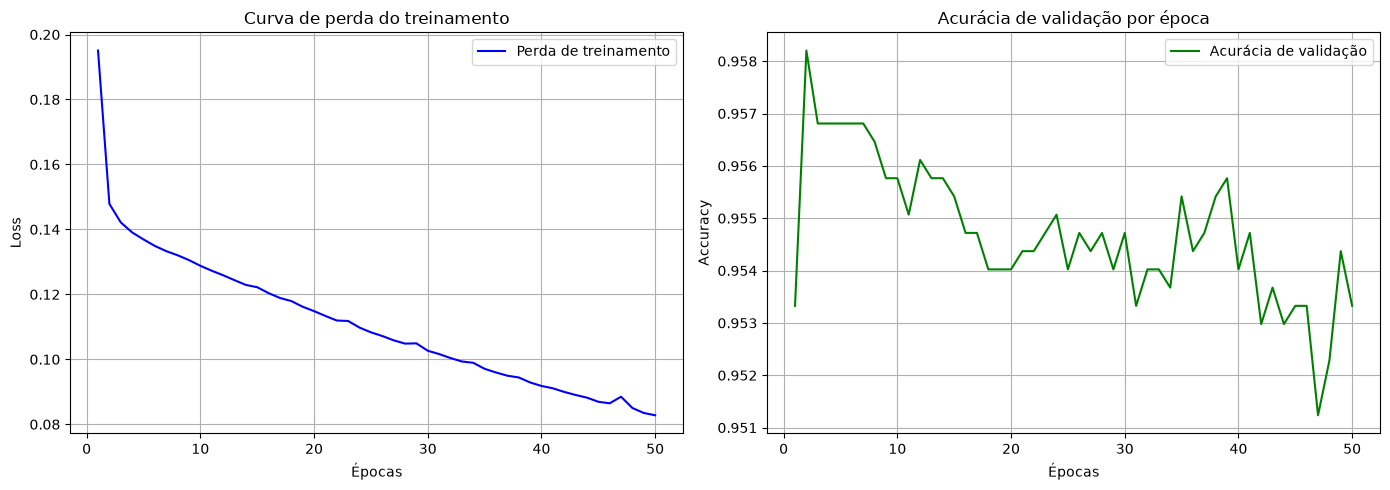


Modelo salvo em: C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/modelo/dl/mlp_model_v3.pkl


In [5]:
# ============================================================
# 10. SEPARAÇÃO ENTRE TREINO E VALIDAÇÃO
# ============================================================

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

# ============================================================
# 11. CRIAÇÃO DO MLP
# ============================================================

mlp = MLPClassifier(
    **MLP_PARAMS
)

# ============================================================
# 12. TREINAMENTO POR ÉPOCA
# ============================================================

loss_treino = []
accuracy_validacao = []

for epoca in range(NUM_EPOCAS):

    mlp.partial_fit(
        X_treino,
        y_treino,
        classes=np.array([0, 1])
    )

    loss_treino.append(
        mlp.loss_
    )

    y_validacao_pred = mlp.predict(
        X_validacao
    )

    accuracy_validacao.append(
        accuracy_score(
            y_validacao,
            y_validacao_pred
        )
    )

    print(
        f"Época {epoca + 1}/{NUM_EPOCAS} | "
        f"Loss: {mlp.loss_:.4f} | "
        f"Validação: {accuracy_validacao[-1]:.4f}"
    )

# ============================================================
# 13. GRÁFICOS DE TREINAMENTO E VALIDAÇÃO
# ============================================================

epocas = range(1, NUM_EPOCAS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 - Perda do treinamento
axes[0].plot(
    epocas,
    loss_treino,
    label="Perda de treinamento",
    color="blue"
)

axes[0].set_title("Curva de perda do treinamento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Gráfico 2 - Acurácia de validação
axes[1].plot(
    epocas,
    accuracy_validacao,
    label="Acurácia de validação",
    color="green"
)

axes[1].set_title("Acurácia de validação por época")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# SALVAMENTO DO MODELO
# ============================================================

modelo = {
    "model": mlp,
    "scaler": scaler,
    "features": X_train.columns.tolist(),
    "threshold": THRESHOLD
}

caminho_modelo = "C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/modelo/dl/mlp_model_v3.pkl"

with open(caminho_modelo, "wb") as arquivo:
    pickle.dump(modelo, arquivo)

print(f"\nModelo salvo em: {caminho_modelo}")

# Gráfico 01
A curva de perda mostra o erro que o modelo apresenta durante o treinamento.

Curva decrescente: o modelo está aprendendo a ajustar seus pesos.

Curva estabilizada: o treinamento pode ter atingido um platô.

Curva crescente: pode indicar instabilidade ou dificuldades de otimização.

# Gráfico 02

A curva de validação mostra como o modelo classifica as amostras reservadas para validação durante o treinamento.

Acurácia crescente: o modelo está melhorando sua capacidade de classificação no conjunto de validação.

Acurácia estabilizada: pode indicar que o modelo deixou de apresentar melhorias.

Acurácia decrescente: pode indicar que o modelo está perdendo capacidade de generalização.

In [6]:
# ============================================================
# 12. PREDIÇÃO
# ============================================================

y_prob = mlp.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_prob >= THRESHOLD
).astype(int)

In [7]:
# ============================================================
# 13. MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_atraso = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall_atraso = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1_atraso = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f2_atraso = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    pos_label=1,
    zero_division=0
)

roc_auc_atraso = roc_auc_score(
    y_test,
    y_prob
)

precision_pr, recall_pr, _ = precision_recall_curve(
    y_test,
    y_prob,
    pos_label=1
)

pr_auc_atraso = auc(
    recall_pr,
    precision_pr
)


RESULTADOS - MLP
Arquitetura: (64, 32, 16)
Activation: relu
Solver: adam
Learning rate: 0.001
Batch size: 64
Épocas máximas: 1
Limiar: 0.90

Quantidade de amostras:
Treino: 28706
Teste:  5114

Métricas:
Accuracy:        0.8790
Precision atraso: 0.4949
Recall atraso:    0.4780
F1 atraso:        0.4863
F2 atraso:        0.4813
ROC-AUC atraso:   0.7757
PR-AUC atraso:    0.5225

Como interpretar as métricas:
- Precision atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- Recall atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- F1 atraso: média harmônica entre precision e recall.
- F2 atraso: semelhante ao F1, mas dando mais peso ao recall.
- ROC-AUC atraso: capacidade do modelo de separar atrasos de não atrasos em diferentes limiares.
- PR-AUC atraso: desempenho no equilíbrio entre precision e recall para a classe atraso.


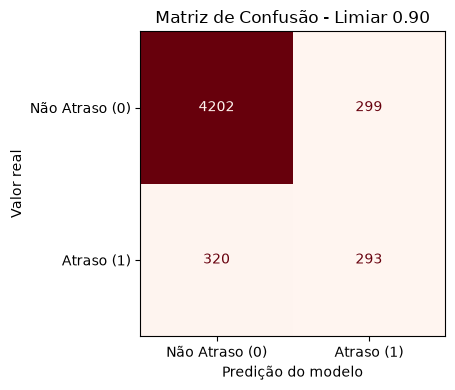


Relatório de classificação:
                precision    recall  f1-score   support

Não Atraso (0)       0.93      0.93      0.93      4501
    Atraso (1)       0.49      0.48      0.49       613

      accuracy                           0.88      5114
     macro avg       0.71      0.71      0.71      5114
  weighted avg       0.88      0.88      0.88      5114


Quantidade de épocas executadas:
1


In [8]:
# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS - MLP")
print("=" * 60)

print(f"Arquitetura: {MLP_PARAMS['hidden_layer_sizes']}")
print(f"Activation: {MLP_PARAMS['activation']}")
print(f"Solver: {MLP_PARAMS['solver']}")
print(f"Learning rate: {MLP_PARAMS['learning_rate_init']}")
print(f"Batch size: {MLP_PARAMS['batch_size']}")
print(f"Épocas máximas: {MLP_PARAMS['max_iter']}")
print(f"Limiar: {THRESHOLD:.2f}")

print("\nQuantidade de amostras:")
print(f"Treino: {len(X_train)}")
print(f"Teste:  {len(X_test)}")

print("\nMétricas:")
print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision atraso: {precision_atraso:.4f}")
print(f"Recall atraso:    {recall_atraso:.4f}")
print(f"F1 atraso:        {f1_atraso:.4f}")
print(f"F2 atraso:        {f2_atraso:.4f}")
print(f"ROC-AUC atraso:   {roc_auc_atraso:.4f}")
print(f"PR-AUC atraso:    {pr_auc_atraso:.4f}")

# ============================================================
# INTERPRETAÇÃO DAS MÉTRICAS
# ============================================================

print("\nComo interpretar as métricas:")
print("- Precision atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- Recall atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- F1 atraso: média harmônica entre precision e recall.")
print("- F2 atraso: semelhante ao F1, mas dando mais peso ao recall.")
print("- ROC-AUC atraso: capacidade do modelo de separar atrasos de não atrasos em diferentes limiares.")
print("- PR-AUC atraso: desempenho no equilíbrio entre precision e recall para a classe atraso.")

# ============================================================
# MATRIZ DE CONFUSÃO
# ============================================================

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Reds",
    ax=ax,
    colorbar=False,
    display_labels=[
        "Não Atraso (0)",
        "Atraso (1)"
    ]
)

ax.set_title(
    f"Matriz de Confusão - Limiar {THRESHOLD:.2f}"
)

ax.set_xlabel("Predição do modelo")
ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

# ============================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ============================================================

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Não Atraso (0)",
            "Atraso (1)"
        ],
        zero_division=0
    )
)

print("\nQuantidade de épocas executadas:")
print(mlp.n_iter_)